# Лабораторная работа №2 «Обнаружение аномалий и выбросов в данных»

## Задание 1. Загрузка и профилирование данных


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('../data/bikes_dirty.csv')
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])

print("Информация:")
df.info()

print("\nCтатистика:")
display(df.describe().T)

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10936 entries, 0 to 10935
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10936 non-null  datetime64[ns]
 1   season      10936 non-null  int64         
 2   holiday     10936 non-null  int64         
 3   workingday  10936 non-null  int64         
 4   weather     10391 non-null  float64       
 5   temp        10936 non-null  float64       
 6   atemp       10936 non-null  float64       
 7   humidity    9817 non-null   float64       
 8   windspeed   10614 non-null  float64       
 9   casual      10936 non-null  int64         
 10  registered  10936 non-null  int64         
 11  count       10936 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(6)
memory usage: 1.0 MB

Cтатистика:


,count,mean,min,25%,50%,75%,max,std
datetime,10936,2011-12-27 05:02:51.506949632,2011-01-01 00:00:00,2011-07-02 08:45:00,2012-01-01 19:30:00,2012-07-01 12:15:00,2012-12-19 23:00:00,NaN
season,10936.0,2.506584,1.0,2.0,3.0,4.0,4.0,1.115773
holiday,10936.0,0.028987,0.0,0.0,0.0,0.0,1.0,0.167777
workingday,10936.0,0.680322,0.0,0.0,1.0,1.0,1.0,0.466373
weather,10391.0,1.419113,1.0,1.0,1.0,2.0,4.0,0.633654
temp,10936.0,20.232915,0.82,13.94,20.5,26.24,41.0,7.795027
atemp,10936.0,23.657563,0.76,16.665,24.24,31.06,45.455,8.479119
humidity,9817.0,61.915453,0.0,47.0,62.0,77.0,250.0,19.314763
windspeed,10614.0,12.800656,0.0,7.0015,12.998,16.9979,56.9969,8.155415
casual,10936.0,36.009967,0.0,4.0,17.0,49.0,367.0,49.943663


### Анализ:

**Анализ по результатам `info()` и `describe()`:**
1. **Наличие пропусков:** В датасете присутствуют пропуски (humidity, weather, windspeed).
2. **Диапазоны значений:** Большинство признаков находятся в нормальных физических пределах (температура, сезоны).
3. **Подозрительные экстремальные значения:**
   - `humidity` имеет максимум `250.0`. Это явная аномалия.
   - `count` имеет среднее ~191, но максимум достигает 977. Это говорит о сильной асимметрии и наличии "хвоста" из выбросов.

### Визуальный анализ:
Выберем признаки: `temp` и `count`.

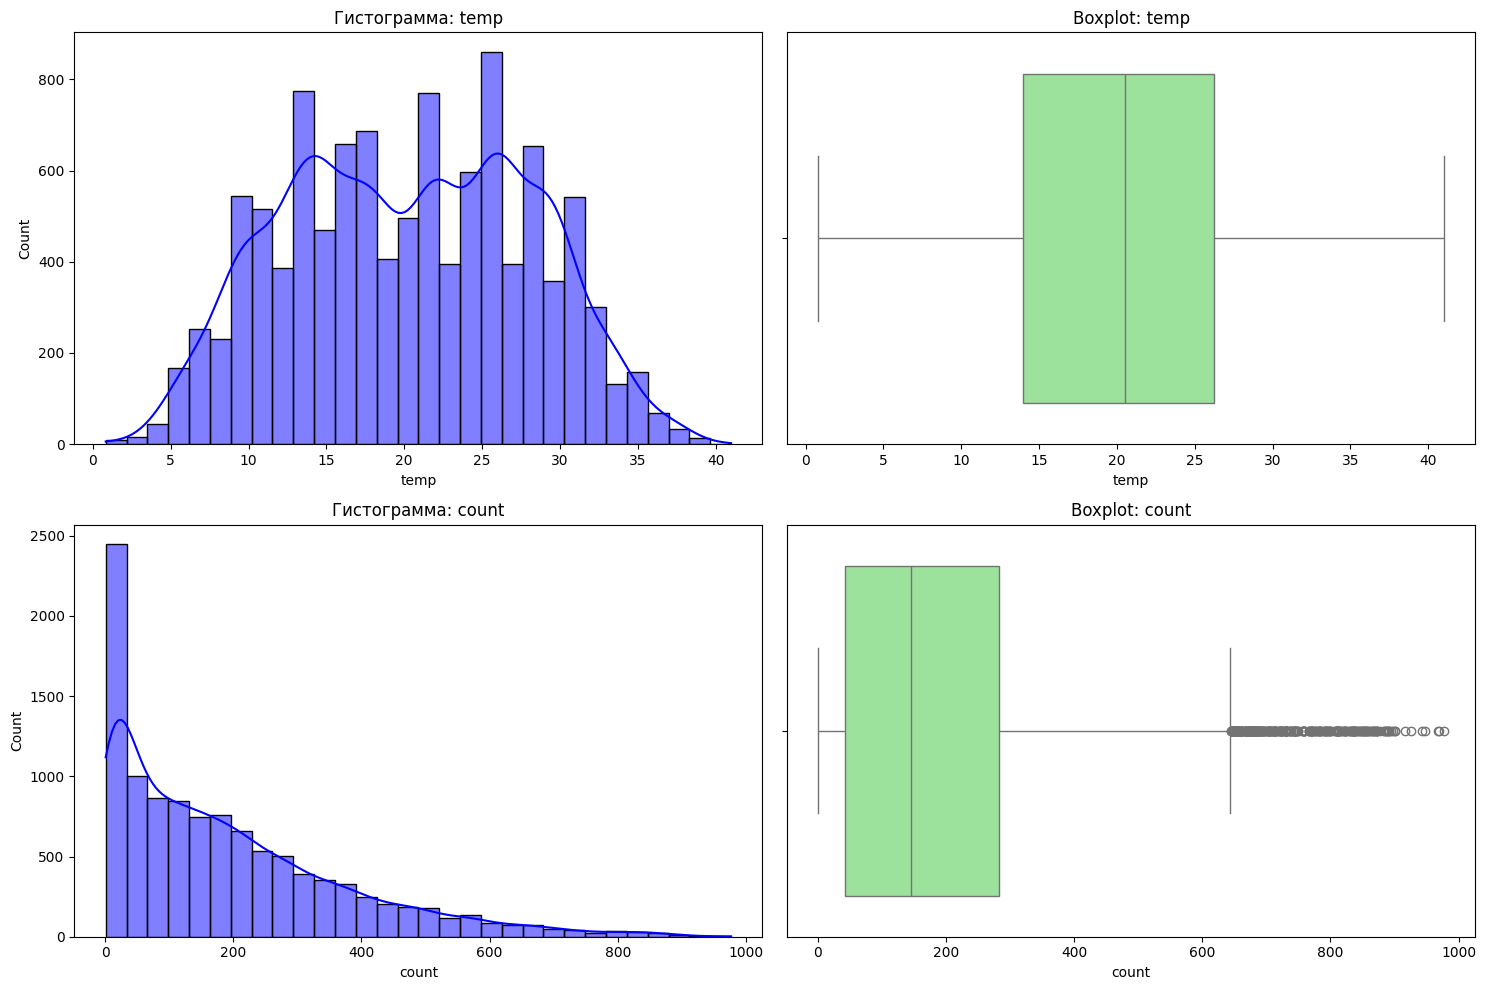

In [4]:
features = ['temp', 'count']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i*2 + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='blue')
    plt.title(f'Гистограмма: {col}')
    plt.xlabel(col)

    plt.subplot(2, 2, i*2 + 2)
    sns.boxplot(x=df[col].dropna(), color='lightgreen')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**Вывод о возможных выбросах:**
*   **`temp`:** Гистограмма выглядит как нормальное симметричное распределение. На Boxplot выбросов совсем нет.
*   **`count`:** Гистограмма сильно скошена. Boxplot показывает огромное количество выбросов за верхней границей. Выбросы же отражают пиковый спрос.

## Задание 2. Проверка нормальности распределения

### Описательные характеристики признаков:

In [5]:
stats_df = pd.DataFrame(index=['Среднее', 'Медиана', 'Ст. отклонение', 'Коэф. ассиметрии', 'Коэф. эксцесса'], columns=features)

for col in features:
    data = df[col].dropna()
    stats_df.loc['Среднее', col] = data.mean()
    stats_df.loc['Медиана', col] = data.median()
    stats_df.loc['Ст. отклонение', col] = data.std()
    stats_df.loc['Коэф. ассиметрии', col] = data.skew()
    stats_df.loc['Коэф. эксцесса', col] = data.kurtosis()

display(stats_df)

,temp,count
Среднее,20.232915,191.428859
Медиана,20.5,145.0
Ст. отклонение,7.795027,181.09322
Коэф. ассиметрии,0.003879,1.242704
Коэф. эксцесса,-0.915987,1.300622


* Для `temp`: коэффициент асимметрии близок к нулю. Коэффициент эксцесса отрицательный (-0.91). Это означает, что распределение является плосковершинным. Распределение визуально относительно нормальное.
* Для `count`: большая положительная асимметрия явно указывает на сильную скошенность распределения и длинный "хвост". Положительный эксцесс (1.30) подтверждает наличие большого количества выбросов. Распределение не нормальное.

### Графический анализ:


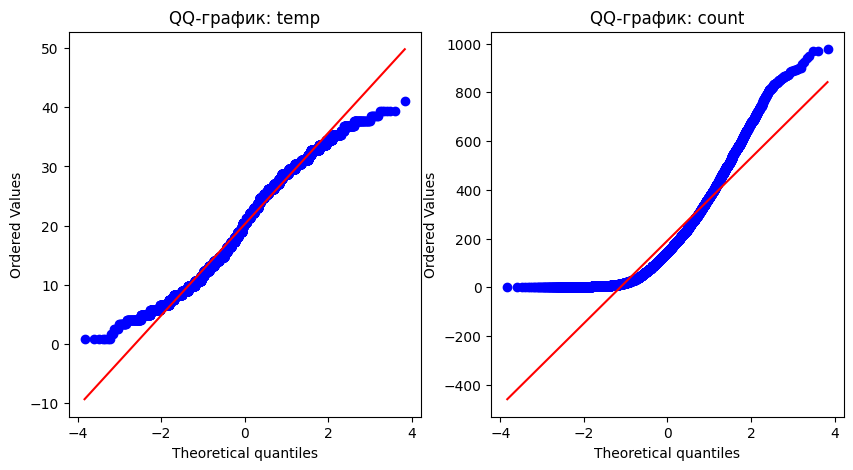

In [16]:
plt.figure(figsize=(10, 5))

for i, col in enumerate(features):
    plt.subplot(1, 2, i+1)
    stats.probplot(df[col].dropna(), plot=plt)
    plt.title(f'QQ-график: {col}')

plt.show()

*   **Сравнение:** Точки признака `temp` в центре плотно ложатся на красную диагональ, что подтверждает его симметричность и близость к нормальному распределению. Точки признака `count` образуют сильную дугу, что является явным признаком отклонения от нормального распределения (наличие сильного правого хвоста).

### Критерий Шапиро–Уилка

**Гипотезы:**
*   **H0:** Выборка подчиняется нормальному распределению.
*   **H1:** Выборка не подчиняется нормальному распределению.
*   Уровень значимости: $\alpha$ = 0.05.


In [7]:
for col in features:
    # подвыборка из 5000
    data = df[col].dropna().sample(n=min(5000, len(df[col].dropna())), random_state=42)

    stat, p_value = stats.shapiro(data)
    print(f"Признак '{col}': Статистика = {stat:.4f}, p-value = {p_value:.4e}")

    if p_value > 0.05:
        print(f"  Принимаем H0: Выборка из '{col}' подчиняется нормальному распределению.\n")
    else:
        print(f"  Отклоняем H0: Выборка из '{col}' не подчиняется нормальному распределению!\n")

Признак 'temp': Статистика = 0.9804, p-value = 9.3524e-26
  Отклоняем H0: Выборка из 'temp' не подчиняется нормальному распределению!

Признак 'count': Статистика = 0.8749, p-value = 4.6429e-53
  Отклоняем H0: Выборка из 'count' не подчиняется нормальному распределению!



**Вывод:** Тест Шапиро-Уилка отклоняет нормальность для обоих признаков. Это типично для реальных больших данных. Но при этом `temp` визуально и статистически намного ближе к нормальному, поэтому статистические методы обнаружения выбросов будем применять к нему.

## Задание 3. Обнаружение выбросов статистическими методами для признака `temp`
### Методы Z-score и IQR:

Метод Z-score:
Количество выбросов (|Z| > 3): 0

Метод IQR:
Q1 = 13.94, Q3 = 26.24, IQR = 12.30
Границы нормы: от -4.51 до 44.69
Количество выбросов: 0


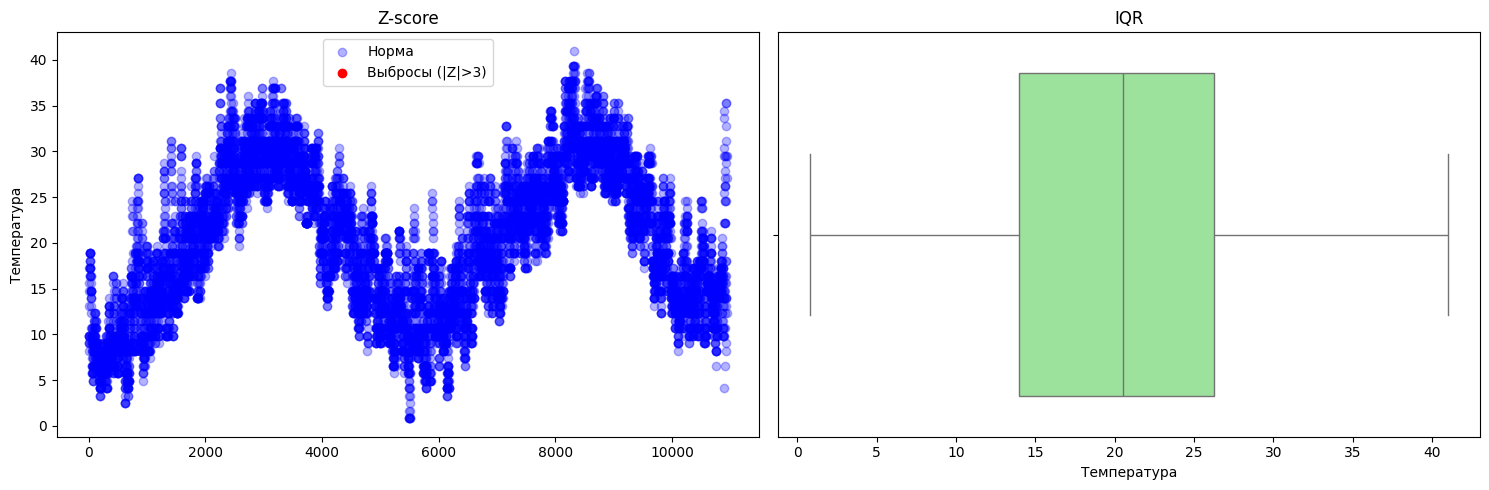

In [8]:
temp_data = df['temp'].dropna()

# Z-score
z_scores = stats.zscore(temp_data)
abs_z_scores = np.abs(z_scores)

outliers_z_mask = abs_z_scores > 3
outliers_z = temp_data[outliers_z_mask]

# IQR
Q1 = temp_data.quantile(0.25)
Q3 = temp_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr_mask = (temp_data < lower_bound) | (temp_data > upper_bound)
outliers_iqr = temp_data[outliers_iqr_mask]

print("Метод Z-score:")
print(f"Количество выбросов (|Z| > 3): {len(outliers_z)}")

print("\nМетод IQR:")
print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Границы нормы: от {lower_bound:.2f} до {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers_iqr)}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(temp_data.index, temp_data.values, color='blue', alpha=0.3, label='Норма')
plt.scatter(outliers_z.index, outliers_z.values, color='red', label='Выбросы (|Z|>3)')
plt.title('Z-score')
plt.ylabel('Температура')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x=temp_data, color='lightgreen')
plt.title('IQR')
plt.xlabel('Температура')

plt.tight_layout()
plt.show()

### Сравнение методов
*   **Z-score** опирается на среднее и стандартное отклонение (чувствителен к выбросам) и рассчитан на нормальное распределение.
*   **IQR** опирается на медиану и квартили, которые устойчивы к отдельным аномалиям. Этот метод более универсальный, так как не требует идеального нормального распределения.
*   В нашем случае оба метода показывают отсутствие выбросов. Это связано с тем, что температура ограничена естественными рамками и имеет плосковершинное распределение, поэтому экстремальных значений нет.

## Задание 4. Метод локальной плотности
Поиск многомерных аномалий в пространстве признаков `temp` и `count`. Используем среднее расстояние до $k$ ближайших соседей ($D_k$) в качестве меры аномальности (чем больше расстояние, тем ниже выше вероятность аномалии).

In [24]:
df_knn = df[['temp', 'count']].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_knn)

scaled_df = pd.DataFrame(X_scaled, columns=['temp_scaled', 'count_scaled'], index=df_knn.index)

def get_knn_distances(X, k, metric='euclidean'):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric).fit(X)
    distances, _ = nbrs.kneighbors(X)
    D_k = distances[:, 1:].mean(axis=1)
    return D_k

### Распределение метрики расстояния
Построим распределение среднего расстояния до k=5 соседей, чтобы визуально определить границу отсечения верхних 5% (аномалий).

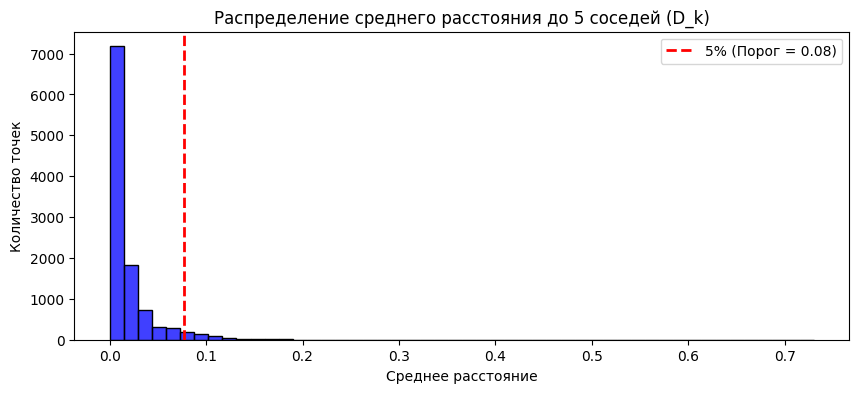

In [25]:
D_k_5 = get_knn_distances(scaled_df, 5)

threshold_5 = np.percentile(D_k_5, 95)

plt.figure(figsize=(10, 4))
sns.histplot(D_k_5, bins=50, color='blue')
plt.axvline(threshold_5, color='red', linestyle='--', linewidth=2, label=f'5% (Порог = {threshold_5:.2f})')
plt.title('Распределение среднего расстояния до 5 соседей (D_k)')
plt.xlabel('Среднее расстояние')
plt.ylabel('Количество точек')
plt.legend()
plt.show()

### Поиск аномалий при различных k
Вычислим расстояния и выделим верхние 5% аномалий для $k \in \{5, 7, 9, 10\}$.

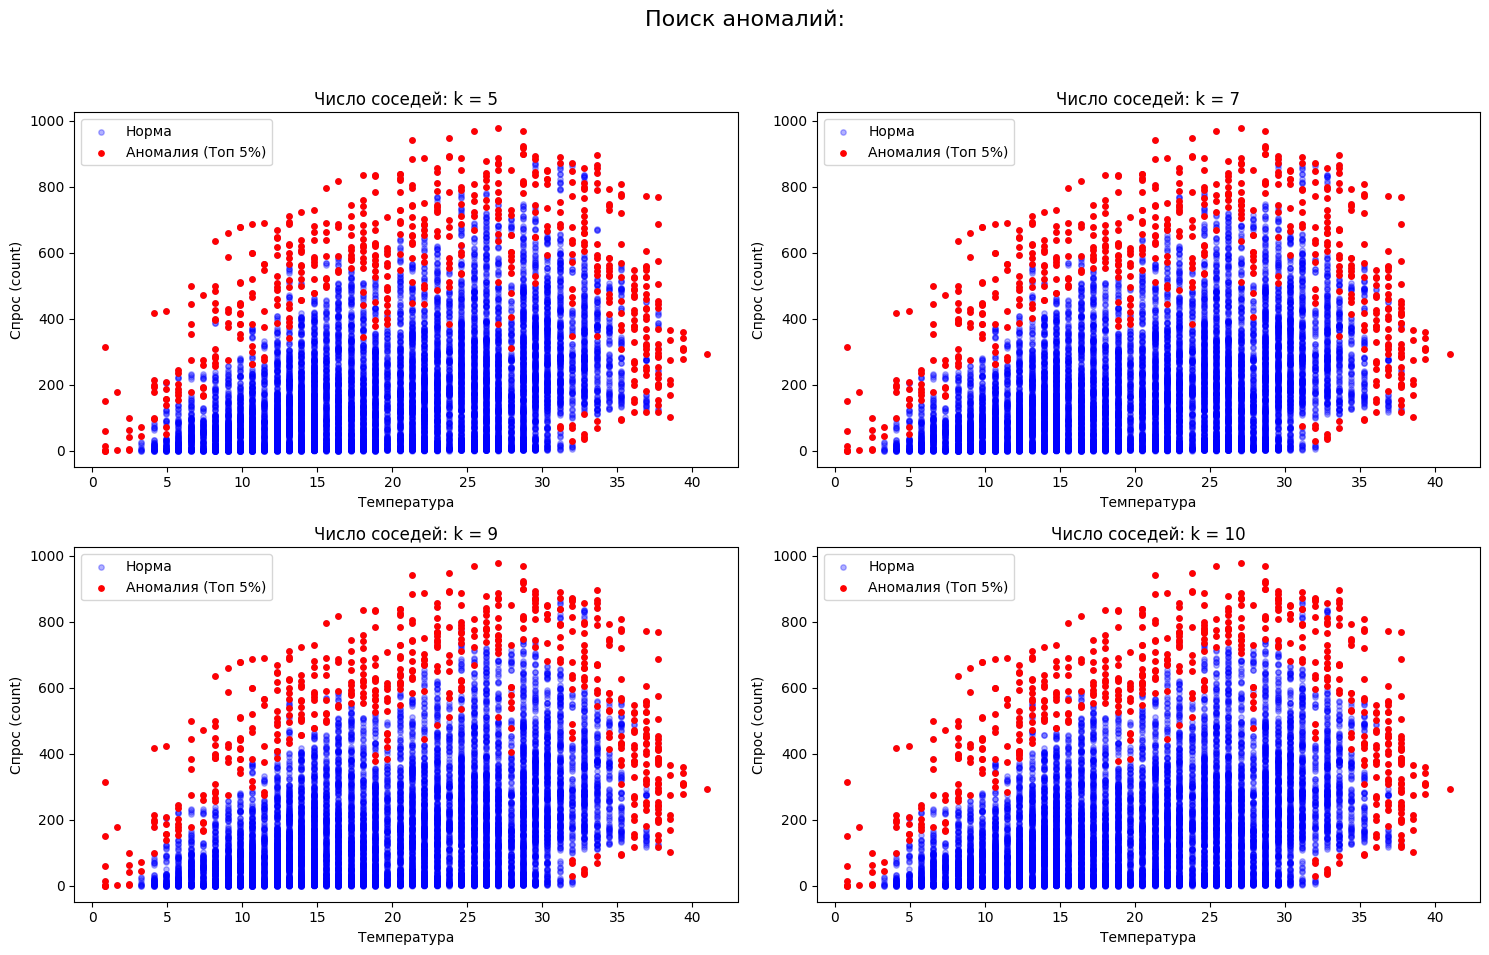

,k,Аномалии
0,5,547
1,7,547
2,9,547
3,10,547


In [43]:
k_values = [5, 7, 9, 10]
anomaly_stats = []

plt.figure(figsize=(15, 10))
plt.suptitle("Поиск аномалий:", fontsize=16)

for i, k in enumerate(k_values):
    D_k = get_knn_distances(X_scaled, k)
    threshold = np.percentile(D_k, 95)
    is_anomaly = D_k > threshold

    num_anomalies = is_anomaly.sum()
    percent_anomalies = (num_anomalies / len(df_knn)) * 100
    anomaly_stats.append({'k': k, 'Аномалии': num_anomalies})

    plt.subplot(2, 2, i+1)
    plt.scatter(df_knn['temp'], df_knn['count'], c='blue', s=15, alpha=0.3, label='Норма')
    plt.scatter(df_knn[is_anomaly]['temp'], df_knn[is_anomaly]['count'], c='red', s=15, label='Аномалия (Топ 5%)')
    plt.title(f'Число соседей: k = {k}')
    plt.xlabel('Температура')
    plt.ylabel('Спрос (count)')
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

stats_df = pd.DataFrame(anomaly_stats)
display(stats_df)

### Сравнение метрик: Евклидово и Манхэттенское расстояние
Проверим, как изменение способа расчета расстояния влияет на результат при фиксированном k=10.

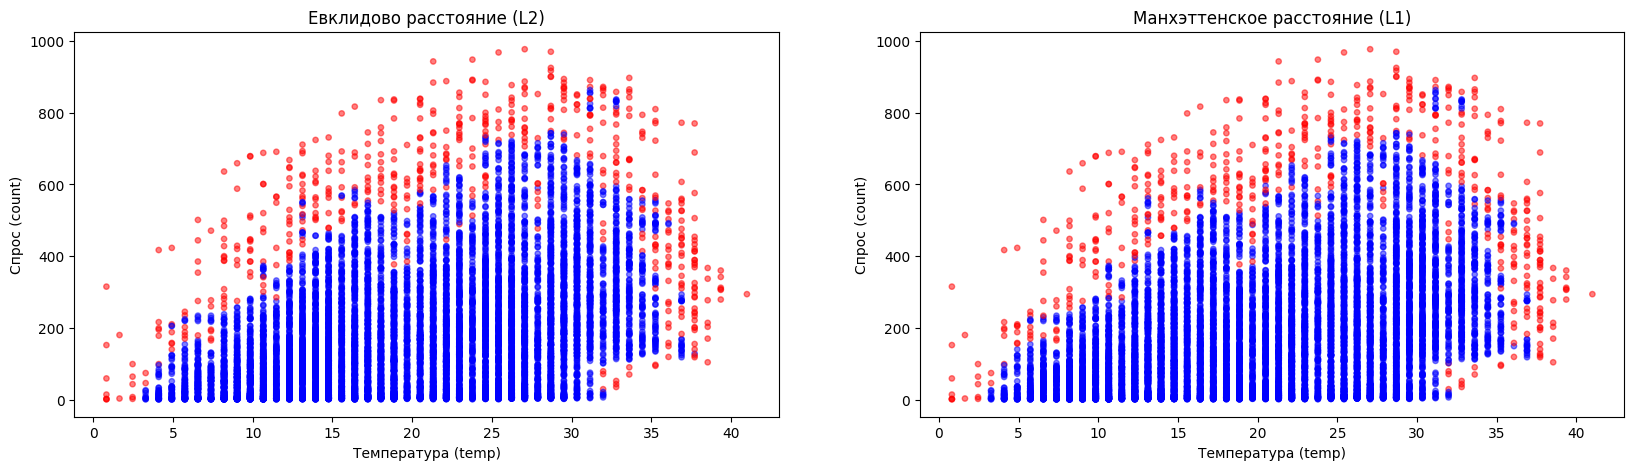

In [44]:
k_fixed = 10
anomaly_stats = []

D_k_eucl = get_knn_distances(scaled_df, k_fixed, metric='euclidean')
D_k_manh = get_knn_distances(scaled_df, k_fixed, metric='manhattan')

is_anom_eucl = D_k_eucl > np.percentile(D_k_eucl, 95)
is_anom_manh = D_k_manh > np.percentile(D_k_manh, 95)

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_knn['temp'], df_knn['count'], c=np.where(is_anom_eucl, 'red', 'blue'), s=15, alpha=0.5)
plt.title('Евклидово расстояние (L2)')
plt.xlabel('Температура (temp)')
plt.ylabel('Спрос (count)')

plt.subplot(1, 2, 2)
plt.scatter(df_knn['temp'], df_knn['count'], c=np.where(is_anom_manh, 'red', 'blue'), s=15, alpha=0.5)
plt.title('Манхэттенское расстояние (L1)')
plt.xlabel('Температура (temp)')
plt.ylabel('Спрос (count)')

plt.show()

### Анализ результатов метода локальной плотности

1. **Интерпретация аномалий:** Алгоритм корректно выделил точки, находящиеся в "разреженных" областях двумерного пространства. Красным цветом выделены:
   * **Глобальные аномалии:** Дни с самым большим пиковым спросом (отдельно стоящие точки в самом верху).
   * **Контекстные аномалии:** Ситуации, когда при комфортной температуре спрос был низок (справа внизу), или высокий спрос в холодную погоду (слева вверху).
2. **Устойчивость к изменению k:** При изменении числа соседей $k \in \{5, 7, 9, 10\}$ алгоритм показывает высокую устойчивость. В основном аномалии (внешний контур) остаются неизменными. При малых $k$ алгоритм более чувствителен к локальному "шуму", а при $k=10$ сильнее выделяет глобальные выбросы. При этом количество аномалий неизменно.
3. **Сравнение метрик:** Евклидово и Манхэттенское расстояния выдали визуально похожий результат, потому что после `StandardScaler` признаки стали сопоставимы по масштабу. Без масштабирования поиск аномалий был бы смещён в сторону признака `count`.